In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Data = pd.read_csv("train.csv")

In [3]:
Data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
Data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("Rows and Columns:", Data.shape)
print("Number of Rows:", Data.shape[0])
print("Number of Columns:", Data.shape[1])

Rows and Columns: (891, 12)
Number of Rows: 891
Number of Columns: 12


In [7]:
missing_values = Data.isnull().sum()
print(missing_values[missing_values > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [8]:
# Numerical Columns
numerical_columns = Data.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(list(numerical_columns))

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [10]:
# Categorical columns
categorical_columns = Data.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


C:\Users\laptop villa\AppData\Local\Temp\ipykernel_18648\1010423723.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = Data.select_dtypes(include=['object']).columns


In [11]:
# Fill missing values in Age with the median
Data["Age"] = Data["Age"].fillna(Data["Age"].median())

# Fill missing values in Embarked with the mode
Data["Embarked"] = Data["Embarked"].fillna(Data["Embarked"].mode()[0])

# Drop the Cabin column because it has too many missing values
Data.drop(columns=["Cabin"], inplace=True)

# Verify that there are no missing values
print(Data.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### Handling Missing Values

The Titanic dataset contains missing values in the **Age**, **Cabin**, and **Embarked** columns. Instead of using `dropna()`, I used `fillna()` for **Age** and **Embarked** to preserve as much data as possible. The **Age** column was filled with the median because it is a numerical feature and the median is less affected by outliers. The **Embarked** column was filled with the mode since it is a categorical feature. The **Cabin** column was removed because it contains a very high number of missing values (687 out of 891), making it less useful for analysis. This approach minimizes data loss while preparing the dataset for machine learning.

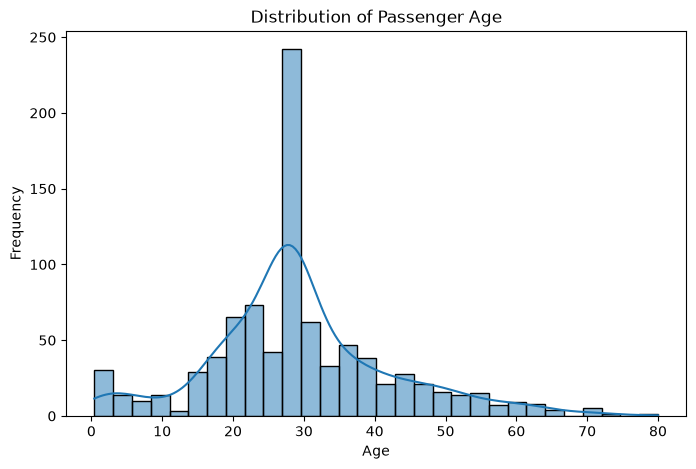

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(Data["Age"], bins=30, kde=True)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

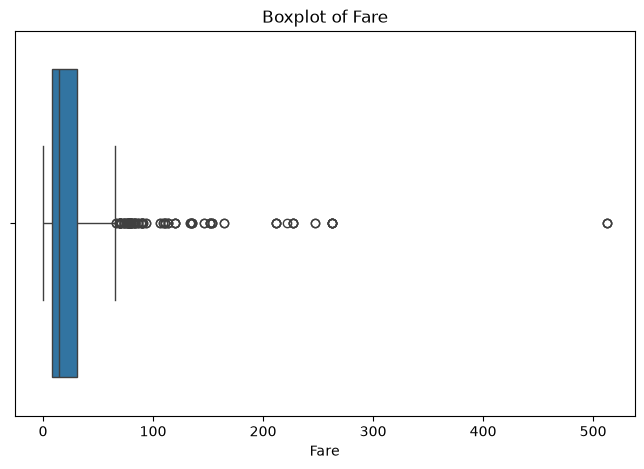

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=Data["Fare"])
plt.title("Boxplot of Fare")
plt.show()

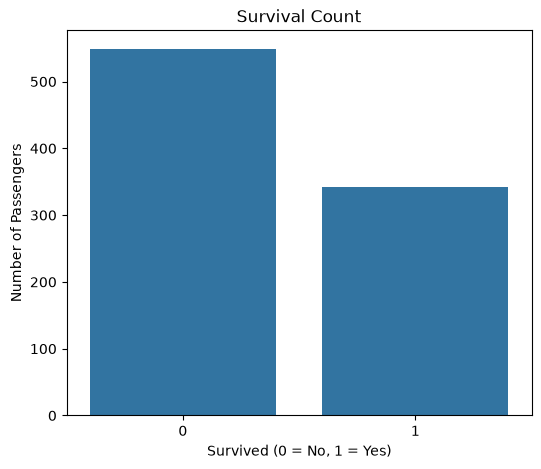

In [16]:
plt.figure(figsize=(6,5))
sns.countplot(x="Survived", data=Data)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

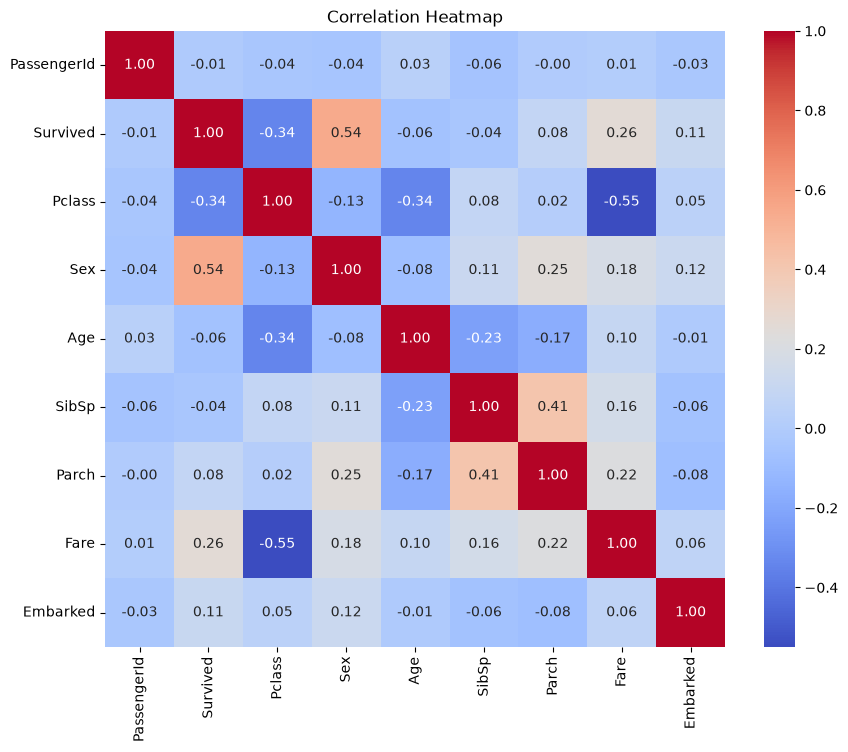

In [19]:
# Select only numeric columns
numeric_df = Data.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

#### Which feature do you think most affects survival, and why?

Based on the exploratory data analysis, I believe the **Sex** feature has the greatest impact on passenger survival. Female passengers had a much higher survival rate than male passengers, which aligns with the historical "women and children first" evacuation policy followed during the Titanic disaster. Other features, such as **Passenger Class (Pclass)** and **Fare**, also appear to influence survival, as first-class passengers generally had better access to lifeboats. However, the difference in survival rates between males and females is the most noticeable, making **Sex** the strongest predictor of survival.